In [7]:
%pip install pandas numpy matplotlib seaborn scipy

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/04/a1/4571fc46e7702de8d0c2dc54ad1b2f8e29328dea3ee90831181f7353d93c/matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-c

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Intel\\climate-challenge-week0\\env\\Lib\\site-packages\\contourpy-1.3.3.dist-info\\METADATA'
Check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd

**Data Loading & Date Parsing**

In [22]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

Load the CSV using pd.read_csv("<country>.csv")


In [37]:
df_eth = pd.read_csv("data/ethiopia.csv")

In [38]:
df_eth.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


Add a Country column with the country name.

In [39]:
df_eth['Country'] = 'Ethiopia'

In [29]:
df_eth.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


Convert the YEAR and DOY columns into a proper datetime column: pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j").

In [40]:
df_eth['Date'] = pd.to_datetime(df_eth["YEAR"] * 1000 + df_eth["DOY"], format="%Y%j")

Extract Month as a separate column. You will need it for seasonal analysis.


In [41]:
df_eth['Month'] = df_eth['Date'].dt.month

In [42]:
df_eth.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


**Summary Statistics & Missing-Value Report**

Replace all occurrences of -999 with np.nan across the entire DataFrame. Do this before running any statistics; -999 is NASA's sentinel value for missing or out-of-range data.

In [43]:
df_eth.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


Run df.duplicated().sum() and drop any duplicate rows. Document how many were found and in which columns.

In [46]:
duplicate_count= df_eth.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


Run df.describe() on all numeric columns and write a brief interpretation in a markdown cell below the output.

In [48]:
df_eth.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


Run df.isna().sum() and compute the percentage of missing values per column.

In [50]:
null_counts = df_eth.isna().sum()
null_percentages = (null_counts / len(df_eth)) * 100

In [51]:
missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage Missing': null_percentages
})

List any column with >5% nulls and note what this might mean for the analysis.

In [52]:
missing = missing_report[missing_report['Percentage Missing'] > 5]
print(missing)

Empty DataFrame
Columns: [Missing Values, Percentage Missing]
Index: []


It shows that all columns have less than 5% null values. This indicates high data completeness. So, the statistical trends and seasonal patterns observed in the Ethiopia dataset can be considered highly representative.

**Outlier Detection & Basic Cleaning**

Compute Z-scores for T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, and WS2M_MAX. Flag rows where |Z| > 3 and report their count.

In [53]:
weather = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [54]:
z_scores = np.abs(stats.zscore(df_eth[weather], nan_policy='omit'))

In [55]:
outlier_mask = (z_scores > 3).any(axis=1)
outliers_count = outlier_mask.sum()
print(f"Number of outliers detected: {outliers_count}")


Number of outliers detected: 132


Decide whether to drop, cap, or retain outlier rows, document your reasoning clearly in a markdown cell.

Decision: Retain the outlier rows. because extreme values often represent real-world phenomena like floods. dropping these would sanitise the dataset and remove the climate signals.ans since the counts are low relative to the total dataset, they won't negatively bias the the general trend.

Handle remaining missing values: apply forward-fill for weather variables, or drop rows if more than 30% of a row's values are missing. Document your decision.

In [57]:
limit = len(df_eth.columns) * 0.7
df_eth.dropna(thresh=limit, inplace=True)

df_eth[weather] = df_eth[weather].ffill()

Export the cleaned DataFrame to data/<country>_clean.csv. Ensure data/ is in .gitignore and never commit CSVs.

In [58]:
import os

In [59]:
output_path = "data/ethiopia_clean.csv"
df_eth.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: data/ethiopia_clean.csv


**Time Series Analysis**

Plot monthly average T2M as a line chart over the full period (2015–2026). Annotate the warmest and coolest months.

In [60]:
df_eth= pd.read_csv('data/ethiopia_clean.csv')

In [63]:
df_eth['Date'] = pd.to_datetime(df_eth['Date'])
df_eth['YearMonth'] = df_eth['Date'].dt.to_period('M')

In [64]:
monthly_data = df_eth.groupby('YearMonth').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum',
    'Date': 'first' 
}).reset_index()

In [65]:
monthly_data = monthly_data.sort_values('Date')

Plot monthly total PRECTOTCORR as a bar chart. Identify and annotate peak rainy season months.

In [66]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

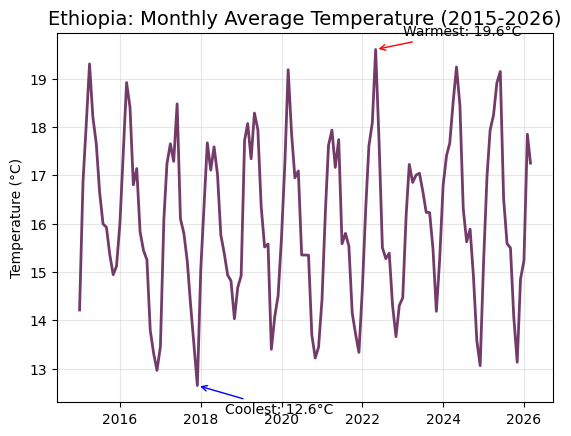

In [73]:
plt.plot(monthly_data['Date'], monthly_data['T2M'], color='#723b69', linewidth=2, label='Avg Temperature')

warmest = monthly_data.loc[monthly_data['T2M'].idxmax()]
coolest = monthly_data.loc[monthly_data['T2M'].idxmin()]

plt.annotate(f"Warmest: {warmest['T2M']:.1f}°C", 
             xy=(warmest['Date'], warmest['T2M']), xytext=(20, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate(f"Coolest: {coolest['T2M']:.1f}°C", 
             xy=(coolest['Date'], coolest['T2M']), xytext=(20, -20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue'))

plt.title("Ethiopia: Monthly Average Temperature (2015-2026)", fontsize=14)
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

The dataset shows a stable temperature pattern. Peaks consistently occur between March and May (Belg), with the lowest temperatures recorded during the main "Kiremt" rains.

The warmest month (19.6°C) recorded around 2022. The coolest month (12.6°C) around 2018.


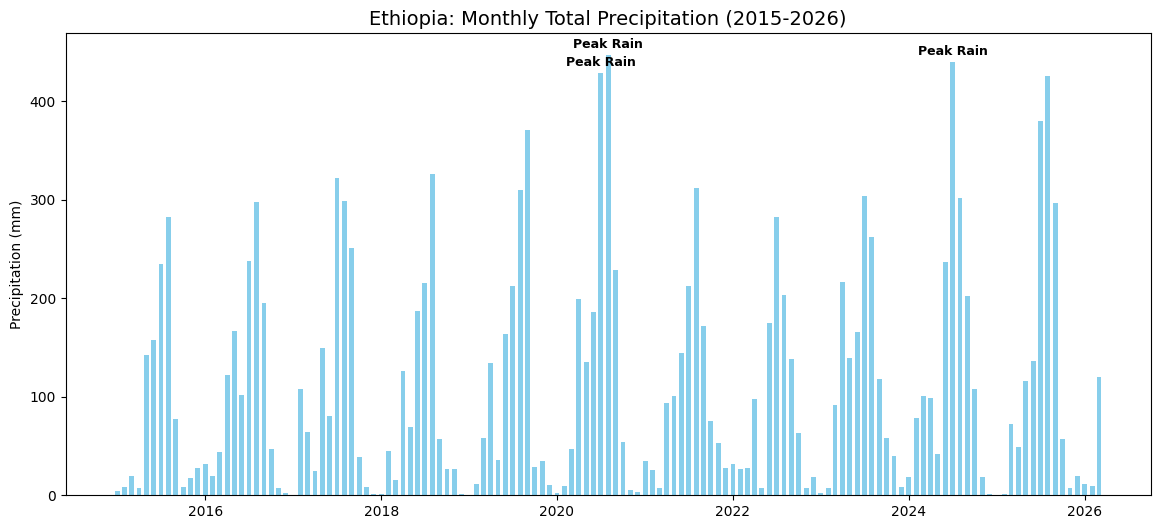

In [72]:
plt.figure(figsize=(14, 6))
plt.bar(monthly_data['Date'], monthly_data['PRECTOTCORR'], color='skyblue', width=20)

peaks = monthly_data.nlargest(3, 'PRECTOTCORR')

for i, row in peaks.iterrows():
    plt.annotate('Peak Rain', 
                 xy=(row['Date'], row['PRECTOTCORR']), 
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=9, fontweight='bold')

plt.title("Ethiopia: Monthly Total Precipitation (2015-2026)", fontsize=14)
plt.ylabel("Precipitation (mm)")
plt.show()

we can clearly see the Kiremt spikes each year. The "Peak Rain" annotations identify the most intense periods, especially that massive surge in 2020/2021 and again in 2024.

**Correlation & Relationship Analysis**

Heatmap of correlations across all numeric columns.

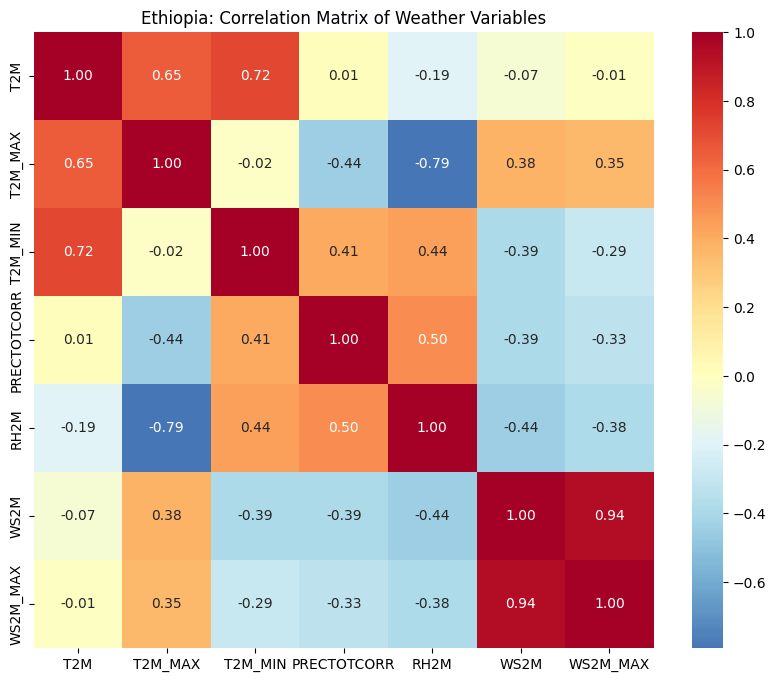

In [74]:
weather = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
corr_matrix = df_eth[weather].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot= True, cmap= 'RdYlBu_r', center=0, fmt='.2f')
plt.title("Ethiopia: Correlation Matrix of Weather Variables")
plt.show()

Scatter plots: T2M vs. RH2M;

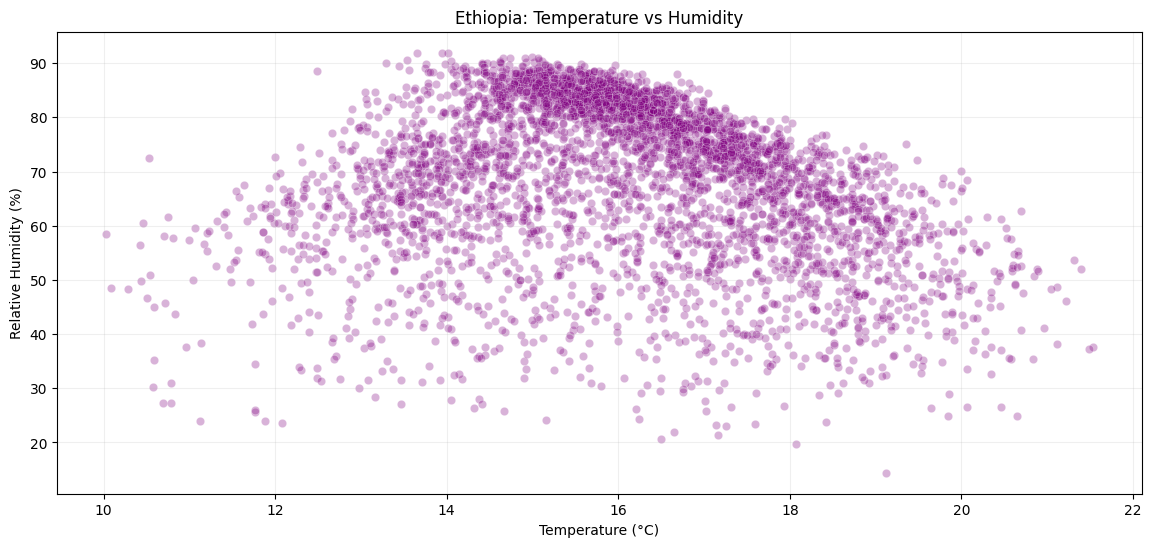

In [75]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_eth, x='T2M', y='RH2M', alpha=0.3, color='purple')
plt.title("Ethiopia: Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, alpha=0.2)
plt.show()

Scatter plots: T2M_RANGE vs. WS2M; 

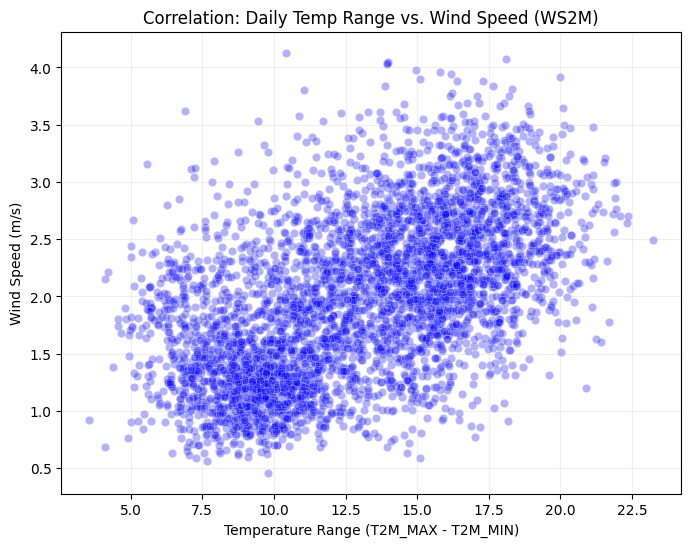

In [78]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_eth, x='T2M_RANGE', y='WS2M', alpha=0.3, color="blue")
plt.title("Correlation: Daily Temp Range vs. Wind Speed (WS2M)")
plt.xlabel("Temperature Range (T2M_MAX - T2M_MIN)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, alpha=0.2)
plt.show()

Identify the three strongest correlations in a markdown cell.

In [79]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
top_pairs = corr_pairs[corr_pairs < 1].head(10)
print("Top 10 Correlated Variable Pairs:")
print(top_pairs)

Top 10 Correlated Variable Pairs:
WS2M         WS2M_MAX       0.940826
WS2M_MAX     WS2M           0.940826
T2M_MIN      T2M            0.724802
T2M          T2M_MIN        0.724802
T2M_MAX      T2M            0.654631
T2M          T2M_MAX        0.654631
RH2M         PRECTOTCORR    0.501347
PRECTOTCORR  RH2M           0.501347
T2M_MIN      RH2M           0.441994
RH2M         T2M_MIN        0.441994
dtype: float64


Interpret the three strongest correlations in a markdown cell.

WS2M & WS2M_MAX - Strong Positive - Daily average wind speeds and maximum gust speeds scale linearly. This consistency allows for predictable wind-energy modeling and indicates that high-wind days also present a higher risk of short-duration extreme wind gusts.

T2M_MIN & T2M - Strong Positive - there is robust linear relationship between nighttime lows and the daily average. This suggests that warm days in Ethiopia are typically preceded by warm nights, indicating consistent air mass temperatures rather than extreme day-night fluctuations.

T2M_MAX & T2M - Strong Positive -	Significant, but less  than the minimums. While daytime solar heating is intense, the overall daily mean is more sensitive to night-to-morning temperature baselines.

**Distribution Analysis**

Histogram of PRECTOTCORR (apply log scale if heavily skewed) and comment on the distribution shape.

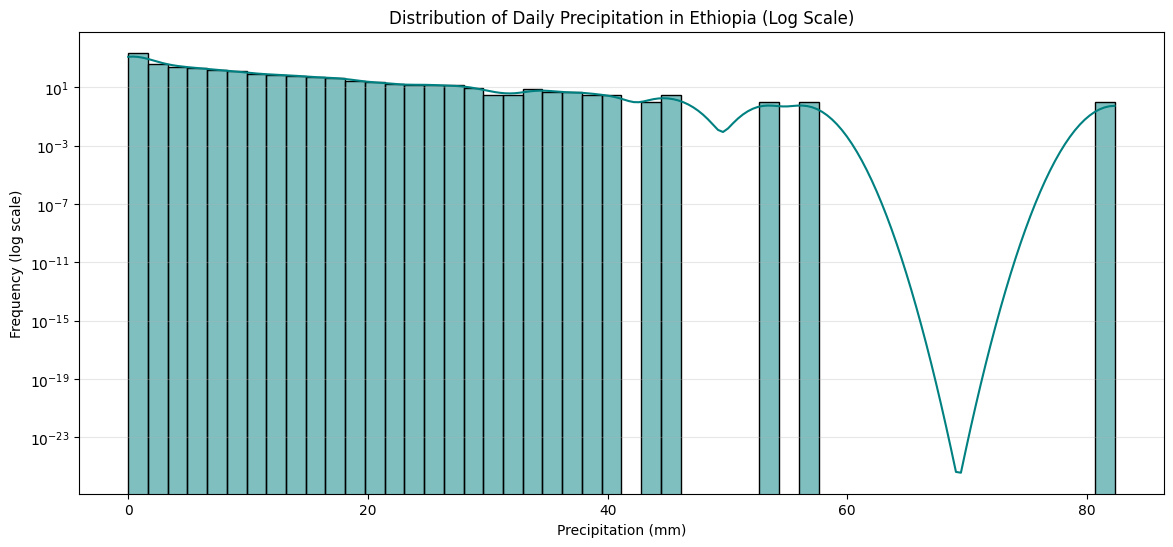

In [80]:
plt.figure(figsize=(14, 6))
sns.histplot(df_eth['PRECTOTCORR'], bins=50, kde=True, color='teal')
plt.yscale('log')
plt.title("Distribution of Daily Precipitation in Ethiopia (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log scale)")
plt.grid(axis='y', alpha=0.3)
plt.show()

"Power Law" shape indicates that Ethiopia's climate is dominated by a high frequency of dry or low-rainfall days.

Bubble chart: T2M vs. RH2M, bubble size = PRECTOTCORR.

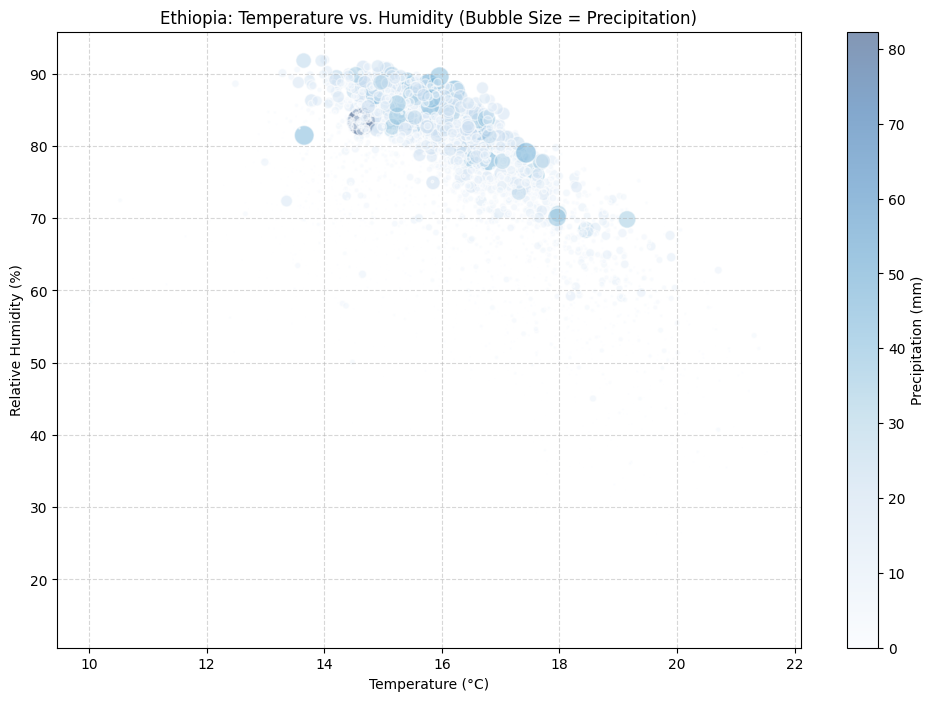

In [ ]:
plt.figure(figsize=(14, 6))

scatter = plt.scatter(
    df_eth['T2M'], 
    df_eth['RH2M'], 
    s=df_eth['PRECTOTCORR'] * 5, 
    c=df_eth['PRECTOTCORR'], 
    cmap='Blues', 
    alpha=0.5, 
    edgecolors='w'
)

plt.colorbar(scatter, label='Precipitation (mm)')
plt.title("Ethiopia: Temperature vs. Humidity (Bubble Size = Precipitation)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

proves that significant rainfall in Ethiopia requires a specific Goldilocks zone of high humidity. If climate change shifts the data points further to the right (higher heat) without increasing humidity, the bubbles will shrink.

**Research & Learning References**

NASA POWER Documentation: Understand the -999 sentinel value and parameter definitions (T2M vs T2M_MAX)

Pandas Documentation: Mastery of .dt accessors for Julian-to-Gregorian date conversion and ffill logic.

Seaborn Statistical Visualization: Best practices for log-scaled histograms and correlation heatmaps.